# Experiment 5: Feature Uncertainty vs Feature Quality

Proposal target: test whether feature-level support uncertainty `U_i = E_b[m_{bi}(1-m_{bi})]` predicts polysemanticity, instability, and weaker feature quality.

This notebook gives a runnable synthetic version with ground-truth decoder recovery and seed stability. It also has an optional hook for external feature-quality scores such as FMS, JS separability, or autointerpretability.


In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "outputs" / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
DEVICE = torch.device("cpu")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebooks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
from scipy.stats import spearmanr

from src.sae_data import SyntheticSparseCodingConfig, make_synthetic_sparse_coding
from src.sae_evaluate import decoder_cosine_matrix, feature_uncertainty
from src.sae_model import VGSAEConfig, VariationalGarroteSAE
from src.sae_train import fit_sae

cfg = SyntheticSparseCodingConfig(
    input_dim=16,
    n_features=32,
    n_samples=768,
    support_density=0.06,
    coherence=0.15,
    noise_std=0.03,
    frequency_skew=1.0,
    seed=20,
)
data = make_synthetic_sparse_coding(cfg, device=DEVICE)
lambda_sparsity = 1.0
seeds = [0, 1, 2]


In [3]:
models = []
for seed in seeds:
    model = VariationalGarroteSAE(
        VGSAEConfig(
            input_dim=cfg.input_dim,
            n_latents=cfg.n_features,
            lambda_sparsity=lambda_sparsity,
            beta=1.0,
        )
    )
    fit_sae(model, data.x, max_steps=300, batch_size=128, lr=3e-3, history_every=100, seed=seed)
    models.append(model)


In [4]:
reference = models[0]
uncertainty = feature_uncertainty(reference, data.x).detach().cpu().numpy()
true_cosines = decoder_cosine_matrix(reference.decoder.weight, data.dictionary)
recovery = true_cosines.max(axis=1)

stability_scores = []
for i in range(reference.config.n_latents):
    scores = []
    ref_vec = reference.decoder.weight[:, i].detach().cpu()
    ref_vec = ref_vec / ref_vec.norm().clamp_min(1e-12)
    for other in models[1:]:
        other_decoder = other.decoder.weight.detach().cpu()
        other_decoder = other_decoder / other_decoder.norm(dim=0, keepdim=True).clamp_min(1e-12)
        scores.append(float(torch.abs(ref_vec @ other_decoder).max()))
    stability_scores.append(np.mean(scores))

quality_df = pd.DataFrame({
    "feature": np.arange(reference.config.n_latents),
    "U_i": uncertainty,
    "decoder_recovery_cosine": recovery,
    "seed_stability_cosine": stability_scores,
})
quality_df["recovery_rank"] = quality_df["decoder_recovery_cosine"].rank(ascending=False)
quality_df.head()


,feature,U_i,decoder_recovery_cosine,seed_stability_cosine,recovery_rank
0,0,0.182188,0.771910,0.793633,10.0
1,1,0.184280,0.543748,0.603442,28.0
2,2,0.182512,0.983341,0.968570,2.0
3,3,0.183256,0.621288,0.586990,17.0
4,4,0.183010,0.803266,0.622145,8.0


In [5]:
for metric in ["decoder_recovery_cosine", "seed_stability_cosine"]:
    corr = spearmanr(quality_df["U_i"], quality_df[metric], nan_policy="omit")
    print(f"Spearman U_i vs {metric}: rho={corr.statistic:.3f}, p={corr.pvalue:.3g}")

external_scores = PROJECT_ROOT / "outputs" / "feature_scores.csv"
if external_scores.exists():
    score_df = pd.read_csv(external_scores)
    merged = quality_df.merge(score_df, on="feature", how="inner")
    for column in [c for c in merged.columns if c not in quality_df.columns]:
        corr = spearmanr(merged["U_i"], merged[column], nan_policy="omit")
        print(f"Spearman U_i vs external {column}: rho={corr.statistic:.3f}, p={corr.pvalue:.3g}")


Spearman U_i vs decoder_recovery_cosine: rho=0.173, p=0.344
Spearman U_i vs seed_stability_cosine: rho=-0.035, p=0.848


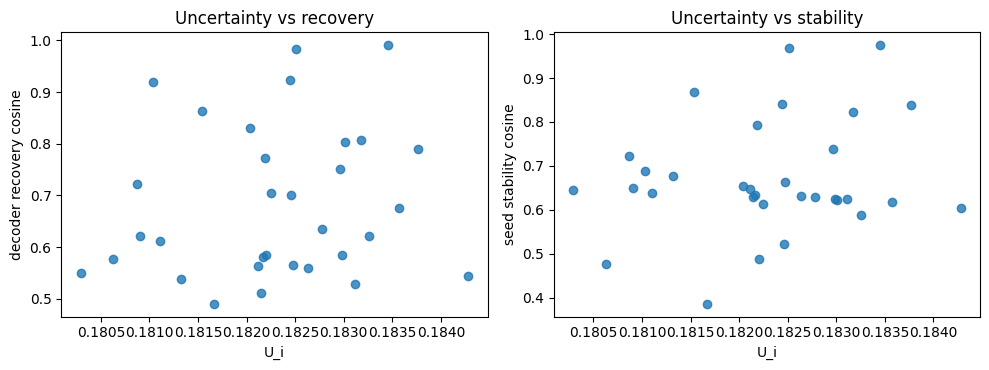

In [6]:
out = OUTPUT_DIR / "exp05_uncertainty_quality"
out.mkdir(parents=True, exist_ok=True)
quality_df.to_csv(out / "feature_uncertainty_quality.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].scatter(quality_df["U_i"], quality_df["decoder_recovery_cosine"], alpha=0.8)
axes[0].set_xlabel("U_i")
axes[0].set_ylabel("decoder recovery cosine")
axes[0].set_title("Uncertainty vs recovery")
axes[1].scatter(quality_df["U_i"], quality_df["seed_stability_cosine"], alpha=0.8)
axes[1].set_xlabel("U_i")
axes[1].set_ylabel("seed stability cosine")
axes[1].set_title("Uncertainty vs stability")
fig.tight_layout()
fig.savefig(out / "feature_uncertainty_quality.png", dpi=160)


**Hard criterion:** if high `U_i` does not anticorrelate with recovery or stability in synthetic ground-truth settings, do not move this claim to real LMs yet. Fix calibration first.
